In [1]:
import moabb
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation
from moabb.paradigms import P300
from hoda import HODA
from sklearn.pipeline import make_pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import matplotlib.pyplot as plt
import seaborn as sns
from moabb.analysis.plotting import paired_plot, meta_analysis_plot, summary_plot
from sklearn.base import BaseEstimator, ClassifierMixin
from toeplitzlda.classification import ToeplitzLDA
from sklearn.svm import SVC
from moabb.analysis.meta_analysis import (  # noqa: E501
    compute_dataset_statistics,
    find_significant_differences,
)

In [2]:
paradigm = P300(resample=32, tmin=0, tmax=1.0, fmin=1, fmax=16)
datasets = [
    BNCI2014008(),
    #BNCI2014009()
]
evaluation = WithinSessionEvaluation(
    paradigm=paradigm, datasets=datasets,
    suffix="examples", overwrite=True,
    data_size=dict(policy='ratio', value=[0.1]), n_perms=[5],
)

In [3]:
pipelines = dict()

pipelines['tHODA+LDA'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    HODA(max_iter=200, rank=(2,2), taper=1, toeplitz=1, shrinkage='oas', solver='svd'),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
)


class ToeplitzLDAWrapper(BaseEstimator, ClassifierMixin):

    def fit(self, X, y=None):
        n_epochs, n_channels, n_samples = X.shape
        self.tlda_ = ToeplitzLDA(n_channels=n_channels, data_is_channel_prime=False)
        X = X.reshape(n_epochs, -1)
        return self.tlda_.fit(X, y)

    def decision_function(self, X):
        n_epochs, n_channels, n_samples = X.shape
        X = X.reshape(n_epochs, -1)
        return self.tlda_.decision_function(X)

    def predict(self, X):
        n_epochs, n_channels, n_samples = X.shape
        X = X.reshape(n_epochs, -1)
        return self.tlda_.predict(X)

    def predict_proba(self, X):
        n_epochs, n_channels, n_samples = X.shape
        X = X.reshape(n_epochs, -1)
        return self.tlda_.predict_proba(X)

pipelines['tLDA'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    ToeplitzLDAWrapper()
)


In [4]:
%prun results = evaluation.process(pipelines)

008-2014-WithinSession: 100%|███████████████████████████████████████████████████████████| 8/8 [01:32<00:00, 11.55s/it]

In [5]:
results

,score,time,samples,data_size,permutation,subject,session,channels,n_sessions,dataset,pipeline
0,0.736745,1.006325,336.0,336.0,1.0,1,session_0,8,1,008-2014,tHODA+LDA
1,0.731133,1.081154,336.0,336.0,2.0,1,session_0,8,1,008-2014,tHODA+LDA
2,0.746143,1.202364,336.0,336.0,3.0,1,session_0,8,1,008-2014,tHODA+LDA
3,0.738092,1.439866,336.0,336.0,4.0,1,session_0,8,1,008-2014,tHODA+LDA
4,0.699673,1.986749,336.0,336.0,5.0,1,session_0,8,1,008-2014,tHODA+LDA
...,...,...,...,...,...,...,...,...,...,...,...
75,0.907633,0.256706,336.0,336.0,1.0,8,session_0,8,1,008-2014,tLDA
76,0.919520,0.245078,336.0,336.0,2.0,8,session_0,8,1,008-2014,tLDA
77,0.900306,0.253785,336.0,336.0,3.0,8,session_0,8,1,008-2014,tLDA
78,0.899092,0.090185,336.0,336.0,4.0,8,session_0,8,1,008-2014,tLDA


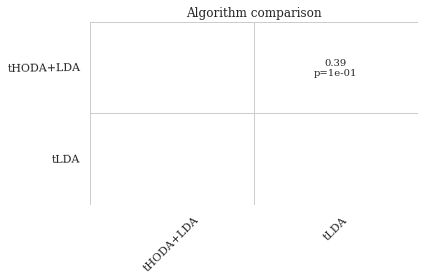

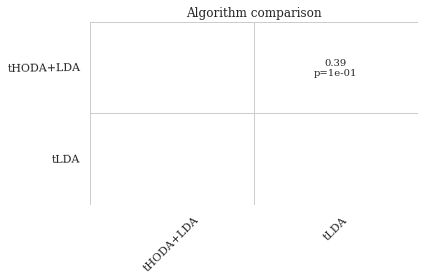

In [6]:
stats = compute_dataset_statistics(results)
P, T = find_significant_differences(stats)
summary_plot(P, T)

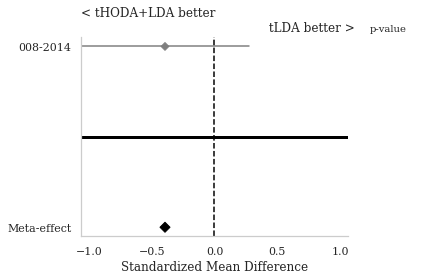

In [7]:
_=meta_analysis_plot(stats, "tLDA", "tHODA+LDA")

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


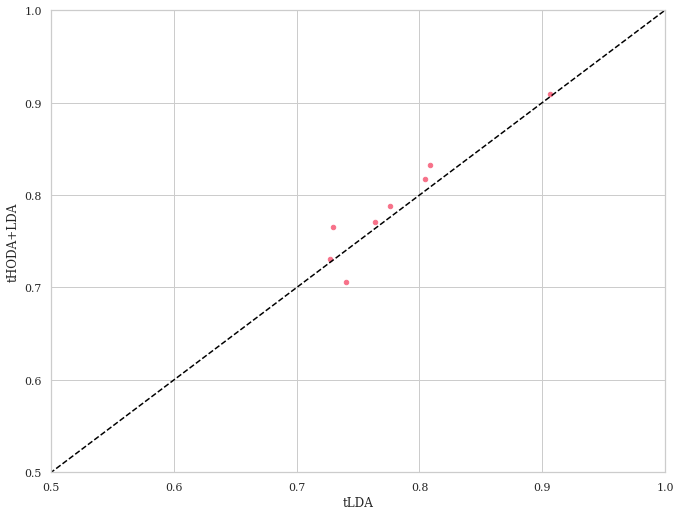

In [8]:
_=paired_plot(results, "tLDA", "tHODA+LDA")